# 多層感知機
:label:`sec_mlp`

在 :numref:`chap_linear`中，
我們介紹了softmax迴歸（ :numref:`sec_softmax`），
然後我們從零開始實現了softmax迴歸（ :numref:`sec_softmax_scratch`），
接著使用高階API實現了演算法（ :numref:`sec_softmax_concise`），
並訓練分類器從低解析度圖像中識別10類服裝。
在這個過程中，我們學習了如何處理資料，如何將輸出轉換為有效的機率分佈，
並應用適當的損失函數，根據模型參數最小化損失。
我們已經在簡單的線性模型背景下掌握了這些知識，
現在我們可以開始對深度神經網路的探索，這也是本書主要涉及的一類模型。

## 隱藏層

我們在 :numref:`subsec_linear_model`中描述了仿射變換，
它是一種帶有偏置項的線性變換。
首先，回想一下如 :numref:`fig_softmaxreg`中所示的softmax迴歸的模型架構。
該模型通過單個仿射變換將我們的輸入直接映射到輸出，然後進行softmax操作。
如果我們的標籤通過仿射變換後確實與我們的輸入資料相關，那麼這種方法確實足夠了。
但是，仿射變換中的*線性*是一個很強的假設。

### 線性模型可能會出錯

例如，線性意味著*單調*假設：
任何特徵的增大都會導致模型輸出的增大（如果對應的權重為正），
或者導致模型輸出的減小（如果對應的權重為負）。
有時這是有道理的。
例如，如果我們試圖預測一個人是否會償還貸款。
我們可以認為，在其他條件不變的情況下，
收入較高的申請人比收入較低的申請人更有可能償還貸款。
但是，雖然收入與還款概率存在單調性，但它們不是線性相關的。
收入從0增加到5萬，可能比從100萬增加到105萬帶來更大的還款可能性。
處理這一問題的一種方法是對我們的資料進行預處理，
使線性變得更合理，如使用收入的對數作為我們的特徵。

然而我們可以很容易找出違反單調性的例子。
例如，我們想要根據體溫預測死亡率。
對體溫高於37攝氏度的人來說，溫度越高風險越大。
然而，對體溫低於37攝氏度的人來說，溫度越高風險就越低。
在這種情況下，我們也可以通過一些巧妙的預處理來解決問題。
例如，我們可以使用與37攝氏度的距離作為特徵。

但是，如何對貓和狗的圖像進行分類呢？
增加位置$(13, 17)$處像素的強度是否總是增加（或降低）圖像描繪狗的似然？
對線性模型的依賴對應於一個隱含的假設，
即區分貓和狗的唯一要求是評估單個像素的強度。
在一個倒置圖像後依然保留類別的世界裡，這種方法注定會失敗。

與我們前面的例子相比，這裡的線性很荒謬，
而且我們難以通過簡單的預處理來解決這個問題。
這是因為任何像素的重要性都以複雜的方式取決於該像素的上下文（周圍像素的值）。
我們的資料可能會有一種表示，這種表示會考慮到我們在特徵之間的相關交互作用。
在此表示的基礎上建立一個線性模型可能會是合適的，
但我們不知道如何手動計算這麼一種表示。
對於深度神經網路，我們使用觀測資料來聯合學習隱藏層表示和應用於該表示的線性預測器。

### 在網路中加入隱藏層

我們可以通過在網路中加入一個或多個隱藏層來克服線性模型的限制，
使其能處理更普遍的函數關係類型。
要做到這一點，最簡單的方法是將許多全連接層堆疊在一起。
每一層都輸出到上面的層，直到生成最後的輸出。
我們可以把前$L-1$層看作表示，把最後一層看作線性預測器。
這種架構通常稱為*多層感知機*（multilayer perceptron），通常縮寫為*MLP*。
下面，我們以圖的方式描述了多層感知機（ :numref:`fig_mlp`）。

![一個單隱藏層的多層感知機，具有5個隱藏單元](../img/mlp.svg)
:label:`fig_mlp`

這個多層感知機有4個輸入，3個輸出，其隱藏層包含5個隱藏單元。
輸入層不涉及任何計算，因此使用此網路產生輸出只需要實現隱藏層和輸出層的計算。
因此，這個多層感知機中的層數為2。
注意，這兩個層都是全連接的。
每個輸入都會影響隱藏層中的每個神經元，
而隱藏層中的每個神經元又會影響輸出層中的每個神經元。

然而，正如 :numref:`subsec_parameterization-cost-fc-layers`所說，
具有全連接層的多層感知機的參數開銷可能會高得令人望而卻步。
即使在不改變輸入或輸出大小的情況下，
可能在參數節約和模型有效性之間進行權衡 :cite:`Zhang.Tay.Zhang.ea.2021`。

### 從線性到非線性

同之前的章節一樣，
我們通過矩陣$\mathbf{X} \in \mathbb{R}^{n \times d}$
來表示$n$個樣本的小批量，
其中每個樣本具有$d$個輸入特徵。
對於具有$h$個隱藏單元的單隱藏層多層感知機，
用$\mathbf{H} \in \mathbb{R}^{n \times h}$表示隱藏層的輸出，
稱為*隱藏表示*（hidden representations）。
在數學或程式碼中，$\mathbf{H}$也被稱為*隱藏層變量*（hidden-layer variable）
或*隱藏變量*（hidden variable）。
因為隱藏層和輸出層都是全連接的，
所以我們有隱藏層權重$\mathbf{W}^{(1)} \in \mathbb{R}^{d \times h}$
和隱藏層偏置$\mathbf{b}^{(1)} \in \mathbb{R}^{1 \times h}$
以及輸出層權重$\mathbf{W}^{(2)} \in \mathbb{R}^{h \times q}$
和輸出層偏置$\mathbf{b}^{(2)} \in \mathbb{R}^{1 \times q}$。
形式上，我們按如下方式計算單隱藏層多層感知機的輸出
$\mathbf{O} \in \mathbb{R}^{n \times q}$：

$$
\begin{aligned}
    \mathbf{H} & = \mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)}, \\
    \mathbf{O} & = \mathbf{H}\mathbf{W}^{(2)} + \mathbf{b}^{(2)}.
\end{aligned}
$$

注意在添加隱藏層之後，模型現在需要追蹤和更新額外的參數。
可我們能從中得到什麼好處呢？在上面定義的模型裡，我們沒有好處！
原因很簡單：上面的隱藏單元由輸入的仿射函數給出，
而輸出（softmax操作前）只是隱藏單元的仿射函數。
仿射函數的仿射函數本身就是仿射函數，
但是我們之前的線性模型已經能夠表示任何仿射函數。

我們可以證明這一等價性，即對於任意權重值，
我們只需合併隱藏層，便可產生具有參數
$\mathbf{W} = \mathbf{W}^{(1)}\mathbf{W}^{(2)}$
和$\mathbf{b} = \mathbf{b}^{(1)} \mathbf{W}^{(2)} + \mathbf{b}^{(2)}$
的等價單層模型：

$$
\mathbf{O} = (\mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)})\mathbf{W}^{(2)} + \mathbf{b}^{(2)} = \mathbf{X} \mathbf{W}^{(1)}\mathbf{W}^{(2)} + \mathbf{b}^{(1)} \mathbf{W}^{(2)} + \mathbf{b}^{(2)} = \mathbf{X} \mathbf{W} + \mathbf{b}.
$$

為了發揮多層架構的潛力，
我們還需要一個額外的關鍵要素：
在仿射變換之後對每個隱藏單元應用非線性的*激活函數*（activation function）$\sigma$。
激活函數的輸出（例如，$\sigma(\cdot)$）被稱為*活性值*（activations）。
一般來說，有了激活函數，就不可能再將我們的多層感知機退化成線性模型：

$$
\begin{aligned}
    \mathbf{H} & = \sigma(\mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)}), \\
    \mathbf{O} & = \mathbf{H}\mathbf{W}^{(2)} + \mathbf{b}^{(2)}.\\
\end{aligned}
$$

由於$\mathbf{X}$中的每一行對應於小批量中的一個樣本，
出於記號習慣的考量，
我們定義非線性函數$\sigma$也以按行的方式作用於其輸入，
即一次計算一個樣本。
我們在 :numref:`subsec_softmax_vectorization`中
以相同的方式使用了softmax符號來表示按行操作。
但是本節應用於隱藏層的激活函數通常不僅按行操作，也按元素操作。
這意味著在計算每一層的線性部分之後，我們可以計算每個活性值，
而不需要查看其他隱藏單元所取的值。對於大多數激活函數都是這樣。

為了構建更通用的多層感知機，
我們可以繼續堆疊這樣的隱藏層，
例如$\mathbf{H}^{(1)} = \sigma_1(\mathbf{X} \mathbf{W}^{(1)} + \mathbf{b}^{(1)})$和$\mathbf{H}^{(2)} = \sigma_2(\mathbf{H}^{(1)} \mathbf{W}^{(2)} + \mathbf{b}^{(2)})$，
一層疊一層，從而產生更有表達能力的模型。

### 通用近似定理

多層感知機可以通過隱藏神經元，捕捉到輸入之間複雜的相互作用，
這些神經元依賴於每個輸入的值。
我們可以很容易地設計隱藏節點來執行任意計算。
例如，在一對輸入上進行基本邏輯操作，多層感知機是通用近似器。
即使是網路只有一個隱藏層，給定足夠的神經元和正確的權重，
我們可以對任意函數建模，儘管實際中學習該函數是很困難的。

神經網路有點像C語言。
C語言和任何其他現代程式語言一樣，能夠表達任何可計算的程式。
但實際上，想出一個符合規範的程式才是最困難的部分。

而且，雖然一個單隱層網路能學習任何函數，
但並不意味著我們應該嘗試使用單隱藏層網路來解決所有問題。
事實上，通過使用更深（而不是更廣）的網路，我們可以更容易地逼近許多函數。
我們將在後面的章節中進行更細緻的討論。

## 激活函數
:label:`subsec_activation_functions`

*激活函數*（activation function）通過計算加權和並加上偏置來確定神經元是否應該被激活，
它們將輸入信號轉換為輸出的可微運算。
大多數激活函數都是非線性的。
由於激活函數是深度學習的基礎，下面(**簡要介紹一些常見的激活函數**)。


In [2]:
%matplotlib inline
import torch

### ReLU函數

最受歡迎的激活函數是*修正線性單元*（Rectified linear unit，*ReLU*），
因為它實現簡單，同時在各種預測任務中表現良好。
[**ReLU提供了一種非常簡單的非線性變換**]。
給定元素$x$，ReLU函數被定義為該元素與$0$的最大值：

(**$$\operatorname{ReLU}(x) = \max(x, 0).$$**)

通俗地說，ReLU函數通過將相應的活性值設為0，僅保留正元素並丟棄所有負元素。
為了直觀感受一下，我們可以畫出函數的曲線圖。
正如從圖中所看到，激活函數是分段線性的。


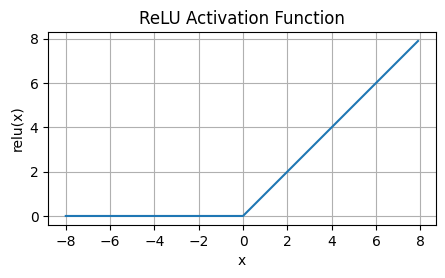

In [3]:
import matplotlib.pyplot as plt

# 創建數據
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)

# 繪圖
plt.figure(figsize=(5, 2.5))
plt.plot(x.detach().numpy(), y.detach().numpy())
plt.xlabel('x')
plt.ylabel('relu(x)')
plt.grid(True)  # 添加網格線
plt.title('ReLU Activation Function')
plt.show()

當輸入為負時，ReLU函數的導數為0，而當輸入為正時，ReLU函數的導數為1。
注意，當輸入值精確等於0時，ReLU函數不可導。
在此時，我們默認使用左側的導數，即當輸入為0時導數為0。
我們可以忽略這種情況，因為輸入可能永遠都不會是0。
這裡引用一句古老的諺語，「如果微妙的邊界條件很重要，我們很可能是在研究數學而非工程」，
這個觀點正好適用於這裡。
下面我們繪製ReLU函數的導數。


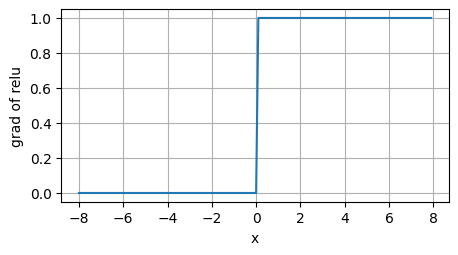

In [4]:
import torch
import matplotlib.pyplot as plt

# 創建數據並計算梯度
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)
y.backward(torch.ones_like(x), retain_graph=True)

# 繪圖
plt.figure(figsize=(5, 2.5))
plt.plot(x.detach(), x.grad)
plt.xlabel('x')
plt.ylabel('grad of relu')
plt.grid()
plt.show()

使用 ReLU 的原因是，它在求導時表現得特別好：要麼讓參數「消失」，要麼讓參數「通過」。
這使得優化過程更順利，同時也減輕了以往神經網路中「梯度消失」的問題（稍後將詳細介紹）。

注意，ReLU 函數有許多變體，包括 參數化 ReLU（Parameterized ReLU，pReLU）函數 
:cite:`He.Zhang.Ren.ea.2015`。
該變體為 ReLU 添加了一個線性項，因此即使參數是負的，某些信息仍然可以通過：

$$\operatorname{pReLU}(x) = \max(0, x) + \alpha \min(0, x).$$

### sigmoid函數

[**對於一個定義域在$\mathbb{R}$中的輸入，
*sigmoid函數*將輸入變換為區間(0, 1)上的輸出**]。
因此，sigmoid通常稱為*擠壓函數*（squashing function）：
它將範圍（-inf, inf）中的任意輸入壓縮到區間（0, 1）中的某個值：

(**$$\operatorname{sigmoid}(x) = \frac{1}{1 + \exp(-x)}.$$**)

在最早期的神經網路中，科學家們對於「激發」或「不激發」的生物神經元建模特別感興趣。
因此，這個領域的先驅可以追溯到人工神經元發明者麥卡洛克和皮茨，他們專注於閾值單元。
閾值單元在其輸入低於某個閾值時的值為0，當輸入超過閾值時的值為1。

當人們逐漸關注到基於梯度的學習時，
sigmoid函數是一個自然選擇，因為它是一個平滑的、可微的閾值單元近似。
當我們想要將輸出視作二元分類問題的概率時，
sigmoid仍然被廣泛用作輸出單元上的激活函數
（sigmoid可以視為softmax的特例）。
然而，sigmoid在隱藏層中已經較少使用，
它在大部分時候被更簡單、更容易訓練的ReLU所取代。
在後面關於循環神經網路的章節中，
我們將描述利用sigmoid單元來控制時序信息流的架構。

下面，我們繪製sigmoid函數。
注意，當輸入接近0時，sigmoid函數接近線性變換。


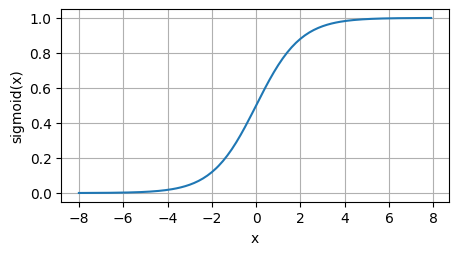

In [5]:
import torch
import matplotlib.pyplot as plt

# 創建數據
x = torch.arange(-8.0, 8.0, 0.1)
y = torch.sigmoid(x)

# 繪圖
plt.figure(figsize=(5, 2.5))
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.grid()
plt.show()

sigmoid函數的導數為下面的公式：

$$\frac{d}{dx} \operatorname{sigmoid}(x) = \frac{\exp(-x)}{(1 + \exp(-x))^2} = \operatorname{sigmoid}(x)\left(1-\operatorname{sigmoid}(x)\right).$$

sigmoid函數的導數圖像如下所示。
注意，當輸入為0時，sigmoid函數的導數達到最大值0.25；
而輸入在任一方向上越遠離0點時，導數越接近0。


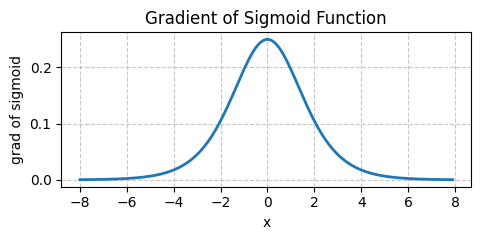

In [6]:
# 清除以前的梯度
# x.grad.data.zero_()
# y.backward(torch.ones_like(x),retain_graph=True)
# d2l.plot(x.detach(), x.grad, 'x', 'grad of sigmoid', figsize=(5, 2.5))
import torch
import matplotlib.pyplot as plt

# 創建數據並計算梯度
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)
y.backward(torch.ones_like(x), retain_graph=True)

# 繪圖
plt.figure(figsize=(5, 2.5))
plt.plot(x.detach(), x.grad, linewidth=2)
plt.xlabel('x')
plt.ylabel('grad of sigmoid')
plt.grid(True, linestyle='--', alpha=0.7)
plt.title('Gradient of Sigmoid Function')
plt.tight_layout()
plt.show()

### tanh函數

與sigmoid函數類似，
[**tanh(雙曲正切)函數也能將其輸入壓縮轉換到區間(-1, 1)上**]。
tanh函數的公式如下：

(**$$\operatorname{tanh}(x) = \frac{1 - \exp(-2x)}{1 + \exp(-2x)}.$$**)

下面我們繪製tanh函數。
注意，當輸入在0附近時，tanh函數接近線性變換。
函數的形狀類似於sigmoid函數，
不同的是tanh函數關於坐標系原點中心對稱。


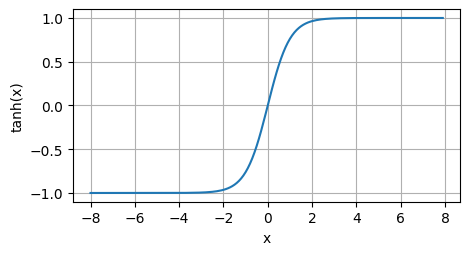

In [7]:
# 創建數據
x = torch.arange(-8.0, 8.0, 0.1)
y = torch.tanh(x)

# 繪圖
plt.figure(figsize=(5, 2.5))
plt.plot(x.detach(), y.detach())
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.grid()
plt.show()

tanh函數的導數是：

$$\frac{d}{dx} \operatorname{tanh}(x) = 1 - \operatorname{tanh}^2(x).$$

tanh函數的導數圖像如下所示。
當輸入接近0時，tanh函數的導數接近最大值1。
與我們在sigmoid函數圖像中看到的類似，
輸入在任一方向上越遠離0點，導數越接近0。


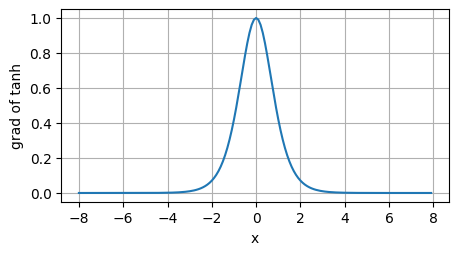

In [9]:
import torch
import matplotlib.pyplot as plt

# 創建數據
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.tanh(x)

# 先計算一次梯度
y.backward(torch.ones_like(x), retain_graph=True)

# 清除梯度
x.grad.zero_()

# 再次計算梯度
y.backward(torch.ones_like(x), retain_graph=True)

# 繪圖
plt.figure(figsize=(5, 2.5))
plt.plot(x.detach(), x.grad)
plt.xlabel('x')
plt.ylabel('grad of tanh')
plt.grid()
plt.show()

總結一下，我們現在了解了如何結合非線性函數來構建具有更強表達能力的多層神經網路架構。
順便說一句，這些知識已經讓你掌握了一個類似於1990年左右深度學習從業者的工具。
在某些方面，你比在20世紀90年代工作的任何人都有優勢，
因為你可以利用功能強大的開源深度學習框架，只需幾行代碼就可以快速構建模型，
而以前訓練這些網路需要研究人員編寫數千行的C或Fortran代碼。

## 小結

* 多層感知機在輸出層和輸入層之間增加一個或一個以上的全連接隱藏層，並通過激活函數轉換隱藏層的輸出。
* 常用的激活函數包括ReLU函數、sigmoid函數和tanh函數。

## 練習

1. 計算pReLU激活函數的導數。
1. 證明一個僅使用ReLU（或pReLU）的多層感知機構造了一個連續的分段線性函數。
1. 證明$\operatorname{tanh}(x) + 1 = 2 \operatorname{sigmoid}(2x)$。
1. 假設我們有一個非線性單元，將它一次應用於一個小批量的數據。這會導致什麼樣的問題？


[Discussions](https://discuss.d2l.ai/t/1796)


# 練習一: 計算pReLU激活函數的導數。

(下面的回答,不一定對) 

Ans:

以下以 $ pReLU(x) = \max(0, x) + \alpha \min(0, x) $ 的定義來計算導數。  
我們可以先將 $ pReLU(x) $ 改寫成分段函數的形式：

$$
pReLU(x) = 
\begin{cases}
x, & \text{如果 } x \ge 0,\\
\alpha x, & \text{如果 } x < 0.
\end{cases}
$$

### 導數的分段計算

1. 當 $ x > 0 $ 時，$ pReLU(x) = x $，其導數為  
   $
   \frac{d}{dx} x = 1.
   $

2. 當 $ x < 0 $ 時，$ pReLU(x) = \alpha x $，其導數為  
   $
   \frac{d}{dx} (\alpha x) = \alpha.
   $

3. 當 $ x = 0 $ 時，嚴格來說在此點上並沒有單一的「純量導數」。  
   - 從左側極限（$ x \to 0^- $）看，函數趨近 $\alpha x$ 的導數為 $\alpha$。  
   - 從右側極限（$ x \to 0^+ $）看，函數趨近 $x$ 的導數為 $1$。  

   在深度學習框架中，通常會以「次導數」（subgradient）的概念處理 $ x=0 $ 的點；  
   如果將 $\alpha$ 視為常數且 $\alpha \neq 1$，則這個點在理論上對應到一個導數值介於 $\alpha$ 與 $1$ 之間的區間。  
   不過在實際實作時，框架或最佳化器往往會直接選擇其中一個值（常見地可能選 $0$、$1$ 或 $\alpha$），  
   或是乾脆忽略此不連續處的定義，採用自動微分工具進行近似。

### 整理

因此，$ pReLU(x) $ 的導數可分段寫成：

$
pReLU'(x) = 
\begin{cases}
1, & x > 0, \\
\alpha, & x < 0, \\
\text{(介於 } \alpha \text{ 與 } 1 \text{之間的次導數)}, & x = 0.
\end{cases}
$

在大部分推導或程式實作中，會簡化為「$ x > 0 $ 時導數 = 1，$ x < 0 $ 時導數 = $\alpha$」，  
而 $ x = 0 $ 的特點則會視需求以各種方式做處理。


# 練習二: 證明一個僅使用ReLU（或pReLU）的多層感知機構造了一個連續的分段線性函數。

(下面的回答,不一定對) 

Ans:

# 證明一個僅使用 ReLU（或 pReLU）的多層感知機構造了一個連續的分段線性函數

以下提供一個較直觀的證明思路，說明「僅使用 ReLU（或 pReLU）之多層感知機（MLP）所表達的函數是 **連續的分段線性函數**」。  
其中，pReLU 與 ReLU 的性質類似，只是當輸入小於 0 時給定了一個可調的斜率 $\alpha$；二者的核心同樣皆為「分段線性」與「連續」。



## 1. 前置概念

### 1.1 線性/仿射轉換（Affine Transformation）

一般全連接層（Fully Connected Layer）對輸入 $\mathbf{x}$ 的運算，可表示為

$$
\mathbf{z} = W \mathbf{x} + \mathbf{b},
$$

其中 $W$ 為矩陣，$\mathbf{b}$ 為偏置向量。此運算在數學上是「仿射轉換」，也是一種類型的線性（嚴格來說是線性加上一個平移）。  
對於任何給定的參數 $W$ 與 $\mathbf{b}$，此運算都是**線性且連續**的。

### 1.2 ReLU 與 pReLU 函數

1. **ReLU**  

   $$
   \operatorname{ReLU}(x) = \max(0, x).
   $$

   它是分段定義的函數，且每個分段皆為線性（$x < 0$ 時輸出 0，$x \ge 0$ 時輸出 $x$），同時在整個實數域上是**連續**且**分段線性**。

2. **pReLU**  

   $$
   \operatorname{pReLU}(x) = \max(0, x) + \alpha \min(0, x),
   $$

   或可寫成分段形式：

   $$
   \operatorname{pReLU}(x) = 
   \begin{cases}
     x, & x \ge 0, \\
     \alpha x, & x < 0.
   \end{cases}
   $$

   這同樣是兩段皆為線性函數，且在整個域上連續。當 $\alpha \neq 0$ 時，負半軸的斜率為 $\alpha$ 而非 0。

---

## 2. 一層（線性 + ReLU/pReLU）的分段線性性質

先考慮一層神經元運算：

$$
\mathbf{h}(\mathbf{x}) = \operatorname{ReLU}\bigl(W\mathbf{x} + \mathbf{b}\bigr) 
\quad\text{或}\quad
\mathbf{h}(\mathbf{x}) = \operatorname{pReLU}\bigl(W\mathbf{x} + \mathbf{b}\bigr).
$$

對每個神經元 $h_i(x)$ 而言：

- 先做線性變換 $\mathbf{z} = W \mathbf{x} + \mathbf{b}$，
- 再經過 ReLU 或 pReLU，皆是**分段線性**函數。

取單一輸出神經元（標量輸出）為例，不失一般性地說明：

$$
h(x) = 
\begin{cases}
  w x + b, & w x + b \ge 0,\\
  \alpha (w x + b), & w x + b < 0.
\end{cases}
$$

（這裡假設使用 pReLU；若 $\alpha = 0$ 則化成標準 ReLU。）

可以看出，對於不同的區域（取決於 $wx + b \ge 0$ 或 < 0），$h(x)$ 都是一條線性函數，因此是**分段線性**的。  
另外，ReLU/pReLU 在切換點（$wx + b = 0$）是**連續**的，故整體函數也**連續**。

---

## 3. 多層（疊加）情況下的推理

多層感知機（MLP）是多層運算的疊加：

$$
f(\mathbf{x}) 
= \underbrace{(L_n \circ \sigma) \circ (L_{n-1} \circ \sigma) \circ \cdots \circ (L_1 \circ \sigma)}_{\text{n 層或更多}}
(\mathbf{x}),
$$

其中：

- $L_i$ 表示第 $i$ 層的線性（或仿射）運算 $W_i \mathbf{x} + \mathbf{b}_i$。  
- $\sigma$ 表示激活函數（ReLU 或 pReLU）。

### 3.1 分段線性的封閉性

事實上，「分段線性函數」在做如下兩種操作後仍然維持分段線性：

1. **與線性（仿射）函數合成**  
   如果 $g(\mathbf{x})$ 是分段線性，且 $L(\mathbf{y})$ 是仿射函數（例如 $W \mathbf{y} + \mathbf{b}$），那麼

   $$
   (L \circ g)(\mathbf{x}) = W \, g(\mathbf{x}) + \mathbf{b}
   $$

   仍是分段線性。因為在每個對應的子區域上，$g(\mathbf{x})$ 皆為線性表達式，與仿射結合後依然是一個線性表達式。

2. **與 ReLU（或 pReLU）合成**  
   如果 $g(\mathbf{x})$ 是分段線性函數，則 $\operatorname{ReLU}(g(\mathbf{x}))$ 也是分段線性；因為

   $$
   \operatorname{ReLU}(g(\mathbf{x})) = \max\{0,\; g(\mathbf{x})\},
   $$

   這等於在 $\mathbf{x}$ 的空間中，進一步按照「$g(\mathbf{x}) \ge 0$」與「$g(\mathbf{x}) < 0$」這兩塊區域去分段，而每塊區域上 $g$ 是線性的、$\max\{0,\cdot\}$ 也只是做了「保留或置 0」的線性操作。  

   pReLU 也是相同原理，只是將「小於 0 那段的輸出」改為 $\alpha \, g(\mathbf{x})$，仍然是線性。

由於多層感知機就是「多次仿射運算與激活函數的重複合成」，而每層都保留**分段線性**與**連續**的性質，最終整個網路映射 $f(\mathbf{x})$ 依然維持**分段線性且連續**。

### 3.2 幾何直覺（切分超平面）

在高維情況下，可以用幾何觀點來理解：

- 每個 ReLU/pReLU 神經元都會引入一個「超平面」 $\{\mathbf{x}\mid w^\top \mathbf{x} + b = 0\}$，此超平面將空間切分為「正」與「負」兩邊；  
- 多層堆疊後，網路會產生眾多由各層神經元所對應的「超平面」交錯，將輸入空間切分成許多「凸多面體」或更複雜的區域；  
- 在每個「切分後的小區域」內，由於所有激活函數對應的正/負判斷都固定，整個網路就退化成（或可以化簡成）一個純粹的線性/仿射映射；  
- 各區域的線性映射拼起來，構成「分段線性」的整體函數，且 ReLU/pReLU 的連續性保證了在區域交界面（超平面）上不會產生不連續跳躍。

---

## 4. 總結

- 一層「線性 + ReLU/pReLU」本身是一個**連續的分段線性函數**。  
- 多層（疊加）之後，藉由「分段線性函數的合成」仍保有分段線性。  
- 每層的激活函數（ReLU/pReLU）皆為連續，因此最終整個多層感知機表達的函數也是連續的。  
- 幾何上，可視為在空間中以多個超平面反覆切割，形成多段區域，每段對應一個純粹的仿射映射，拼合即成為「分段線性」函數。

所以，可以**證明（或理解）一個只使用 ReLU（或 pReLU）的多層感知機，所建構的函數必定是連續的分段線性函數**。  
這個性質在許多深度學習的理論與可視化分析中都相當關鍵，也能幫助我們更好地理解這些神經網路在不同區域的行為。




# 練習三: 證明$\operatorname{tanh}(x) + 1 = 2 \operatorname{sigmoid}(2x)$。

(下面的回答,不一定對) 

Ans:


以下以初等方法證明此恆等式。

---

## 1. 函數定義回顧

1. **雙曲正切函數 (Hyperbolic Tangent)**  
   $$
   \operatorname{tanh}(x)
   = \frac{e^x - e^{-x}}{e^x + e^{-x}}.
   $$

2. **sigmoid 函數**  
   $$
   \operatorname{sigmoid}(z)
   = \frac{1}{1 + e^{-z}}
   = \frac{e^z}{e^z + 1}.
   $$

---

## 2. 推導過程

### 2.1 計算 $\operatorname{tanh}(x) + 1$

先展開 $\operatorname{tanh}(x)$ 並加上 1：

$$
\operatorname{tanh}(x) + 1 
= \frac{e^x - e^{-x}}{e^x + e^{-x}} + 1.
$$

將「1」寫成 $\frac{e^x + e^{-x}}{e^x + e^{-x}}$，得到

$$
\operatorname{tanh}(x) + 1 
= \frac{e^x - e^{-x}}{e^x + e^{-x}}
  + \frac{e^x + e^{-x}}{e^x + e^{-x}}
= \frac{(e^x - e^{-x}) + (e^x + e^{-x})}{e^x + e^{-x}}.
$$

分子可以合併：

$$
(e^x - e^{-x}) + (e^x + e^{-x}) = 2 e^x.
$$

所以

$$
\operatorname{tanh}(x) + 1
= \frac{2 e^x}{e^x + e^{-x}}.
$$

---

### 2.2 計算 $2 \operatorname{sigmoid}(2x)$

由定義可得

$$
\operatorname{sigmoid}(2x)
= \frac{1}{1 + e^{-2x}}
= \frac{e^{2x}}{e^{2x} + 1}.
$$

因此

$$
2 \operatorname{sigmoid}(2x)
= 2 \cdot \frac{e^{2x}}{e^{2x} + 1}.
$$

為了與前一步的形式對照，我們再將 $e^{2x}$ 寫成 $(e^x)^2$：

$$
2 \operatorname{sigmoid}(2x)
= \frac{2 e^{2x}}{e^{2x} + 1}
= \frac{2 (e^x)^2}{(e^x)^2 + 1}.
$$

接下來，我們可以讓 $u = e^x$，那麼 $(e^x)^2 = e^{2x}$。  
同時，注意到 $e^x + e^{-x} = u + \frac{1}{u} = \frac{u^2 + 1}{u}$。  
所以：

$$
\frac{2 e^x}{e^x + e^{-x}}
= 2 \cdot \frac{u}{u + \frac{1}{u}}
= 2 \cdot \frac{u}{\frac{u^2 + 1}{u}}
= \frac{2 u^2}{u^2 + 1}.
$$

由此可見：

$$
\frac{2 u^2}{u^2 + 1}
\quad\text{與}\quad
\frac{2 e^{2x}}{e^{2x} + 1}
$$

其形式完全一致。也就是說

$$
\frac{2 e^x}{e^x + e^{-x}}
= \frac{2 e^{2x}}{e^{2x} + 1}.
$$

綜合以上結果，可知

$$
\operatorname{tanh}(x) + 1
= \frac{2 e^x}{e^x + e^{-x}}
= 2 \cdot \frac{e^{2x}}{e^{2x} + 1}
= 2 \operatorname{sigmoid}(2x).
$$

---

## 3. 總結

透過直接對分子與分母進行拆解與合併，可以很容易看出：

$$
\boxed{
\operatorname{tanh}(x) + 1 
= 2 \operatorname{sigmoid}(2x).
}
$$

此恆等式在許多深度學習與機率模型的 derivation 中相當常見，也能幫助快速將 $\tanh$ 與 $\operatorname{sigmoid}$ 做對應關係。




# 練習四: 假設我們有一個非線性單元，將它一次應用於一個小批量的數據。這會導致什麼樣的問題？

(下面的回答,不一定對) 

Ans:


在深度學習或一般的神經網路中，非線性函數（如 ReLU、sigmoid 等）通常需要**逐元素（element-wise）**或**逐樣本（sample-wise）**應用於輸入資料。  
以下說明如果我們只是「對整個小批量一次性地應用非線性」可能產生的問題：

---

## 1. 維度不匹配與操作定義不明

1. **非線性函數預設逐元素操作**  
   - 通常，我們的非線性函數定義在標量（或向量的逐元素）層面。  
   - 若把整個批次的資料拼成一個“大向量”或“大矩陣”之後僅做「一次非線性映射」，在數學上便失去了原本對「每個樣本」或「每個特徵」分開作用的意義。

2. **維度可能不符**  
   - 例如，假設批次大小是 `batch_size = B`，且每個樣本有 `d` 維特徵，理論上我們在前向傳播時會產生一個 `(B, d)` 的輸入張量，然後對此張量進行逐元素非線性操作。  
   - 如果我們「一次性」地把 `(B, d)` 當成「一個輸入」丟進非線性函數，函數可能被迫視為要將一個 `(B*d)` 維的向量映射到某種空間，或是維度根本對不上，引發**維度錯誤**或**操作意義不清**。

---

## 2. 損失細粒度資訊，無法針對個別樣本做映射

1. **非線性激活的本意**  
   - 非線性激活函數最主要的功能是對「每個神經元的輸出」加上非線性扭曲，使得網路能夠逼近複雜的非線性函數。  
   - 若我們只在「整批資料綜合的某個量」上做一次非線性（而非針對每個樣本、每個特徵），就失去了對「個別樣本特徵」進行非線性變換的能力。

2. **損失對各樣本的區分度**  
   - 一次性操作可能把整個批次混在一起，好比把所有樣本的資訊一起「壓縮」後再做非線性變換；這會讓網路難以區分不同樣本之間的細微差異，**無法針對不同輸入做對應的梯度更新**。
   - 在訓練時，也會導致梯度回傳的過程變得含混不清，因為每個樣本對「整體非線性映射的輸出」的貢獻難以分開。

---

## 3. 擾亂梯度傳播與學習流程

1. **反向傳播的機制**  
   - 深度網路中的反向傳播（backpropagation）在計算每個樣本的損失時，需要對應每個神經元的輸出與權重產生正確的偏導數。  
   - 如果只有「一次性」地套用非線性，就無法清晰定義「針對樣本 $i$、特徵 $j$ 的輸出」對「參數」的偏導數為何，因而破壞了正常的學習機制。

2. **失去並行運算與向量化優勢**  
   - 以小批量（mini-batch）方式處理資料，原本的用意是**並行運算**和**向量化**，並同時保留「逐樣本」的損失與梯度。  
   - 若把整個 batch 一次性地經過非線性映射，不但違背了原本的批次處理邏輯，也會讓程序複雜化，甚至可能需要額外分解或攤平再重塑（reshape），增加不必要的運算和維度混亂。

---

## 4. 小結

- **非線性激活函數應該逐元素或逐樣本應用**：  
  這是神經網路中「非線性性」得以充分發揮的關鍵。 
- **一次性套用於整個批次**會帶來的問題包括：  
  1. 失去對個別樣本/特徵的細粒度操作。  
  2. 維度不匹配及操作意義上的混亂。  
  3. 破壞正常的反向傳播與梯度計算。  
  4. 失去並行向量化處理的優勢或目的。

簡言之，對於深度學習中的批次（batch），每個樣本在同一層中都需要**獨立地**應用非線性單元，才能正確且有效地進行前向傳播與反向傳播。

